<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climas_brasil/blob/main/koppen_thornthwaite_camargo_brasil_terraclimate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Köppen-Geiger, Thornthwaite e Camargo (Maluf 2000) — Brasil, TerraClimate 1991–2020
___

## 1. Setup

In [1]:
!pip install -q earthengine-api geemap rasterio geopandas cartopy matplotlib-scalebar   -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.8 MB/s eta 0:00:00


In [32]:
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import os, glob
import rasterio
from rasterio.merge import merge as rio_merge
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar

import requests
from getpass import getpass
import unicodedata, time

import warnings
from cartopy.io import DownloadWarning

In [3]:
ee.Authenticate()
ee.Initialize(project='fcoliveira')  # Insira o nome do seu projeto no GEE

## 2. Área de estudo — estados do Brasil

In [4]:
states_fc = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))
brazil_geom = states_fc.geometry().dissolve(maxError=1000)
STATE_NAMES = sorted(states_fc.aggregate_array('ADM1_NAME').getInfo())
print(f'{len(STATE_NAMES)} estados/DF encontrados:')
print(STATE_NAMES)

31 estados/DF encontrados:
['Acre', 'Alagoas', 'Amapa', 'Amazonas', 'Bahia', 'Ceara', 'Distrito Federal', 'Espirito Santo', 'Goias', 'Maranhao', 'Mato Grosso', 'Mato Grosso Do Sul', 'Minas Gerais', 'Name Unknown', 'Name Unknown', 'Name Unknown', 'Name Unknown', 'Para', 'Paraiba', 'Parana', 'Pernambuco', 'Piaui', 'Rio De Janeiro', 'Rio Grande Do Norte', 'Rio Grande Do Sul', 'Rondonia', 'Roraima', 'Santa Catarina', 'Sao Paulo', 'Sergipe', 'Tocantins']


## 3. Pipeline TerraClimate → variáveis-base → 3 classificações

In [5]:
tc = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE').filterDate('1991-01-01', '2020-12-31')
months = ee.List.sequence(1, 12)
NATIVE_SCALE = tc.first().select('pr').projection().nominalScale().getInfo()
print('Resolução nativa do TerraClimate (m):', NATIVE_SCALE)

SUMMER_M = [10, 11, 12, 1, 2, 3]
WINTER_M = [4, 5, 6, 7, 8, 9]
W_SUMMER = {12: 1/3, 1: 1, 2: 1, 3: 2/3}
W_AUTUMN = {3: 1/3, 4: 1, 5: 1, 6: 1/3}
W_WINTER = {6: 2/3, 7: 1, 8: 1, 9: 2/3}
W_SPRING = {9: 1/3, 10: 1, 11: 1, 12: 2/3}

Resolução nativa do TerraClimate (m): 4638.312116386398


In [6]:
def clim_mensal(var_name, scale, smooth):
    def per_month(m):
        m = ee.Number(m)
        # Ensure each image is cast to float before taking the mean.
        img = (tc.filter(ee.Filter.calendarRange(m, m, 'month'))
                 .select(var_name).map(lambda i: i.toFloat()).mean().multiply(scale))
        if smooth:
            img = img.resample('bilinear')   # suaviza a interpolação em reprojeções/exports futuros
        return img.set('month', m)
    return ee.ImageCollection.fromImages(months.map(per_month))

def get_terraclimate_monthly(aoi_geom, smooth=True):
    """Retorna listas de 12 imagens mensais (jan->dez) já clipadas ao AOI, para cada variável."""
    tmin = clim_mensal('tmmn', 0.1, smooth)
    tmax = clim_mensal('tmmx', 0.1, smooth)
    pr   = clim_mensal('pr',   1.0, smooth)
    pet  = clim_mensal('pet',  0.1, smooth)
    defi = clim_mensal('def',  0.1, smooth)
    ro   = clim_mensal('ro',   1.0, smooth)

    def tmean_month(m):
        m = ee.Number(m)
        tn = tmin.filter(ee.Filter.eq('month', m)).first()
        tx = tmax.filter(ee.Filter.eq('month', m)).first()
        return tn.add(tx).divide(2).set('month', m)
    tmean = ee.ImageCollection.fromImages(months.map(tmean_month))

    def month_img(coll, m):
        return coll.filter(ee.Filter.eq('month', m)).first().clip(aoi_geom)

    return {
        'tmean': [month_img(tmean, m) for m in range(1, 13)],
        'pr':    [month_img(pr,    m) for m in range(1, 13)],
        'pet':   [month_img(pet,   m) for m in range(1, 13)],
        'def':   [month_img(defi,  m) for m in range(1, 13)],
        'ro':    [month_img(ro,    m) for m in range(1, 13)],
    }

In [7]:
def stack_sum(bands):  return ee.ImageCollection(bands).sum()
def stack_mean(bands): return ee.ImageCollection(bands).mean()
def stack_min(bands):  return ee.ImageCollection(bands).min()
def stack_max(bands):  return ee.ImageCollection(bands).max()
def sel_months(bands, months_list): return [bands[m - 1] for m in months_list]

def weighted_season(bands, weights):
    imgs = [bands[m - 1].multiply(w) for m, w in weights.items()]
    return ee.ImageCollection(imgs).sum()

def compute_base_variables(mb):
    """mb = dicionário retornado por get_terraclimate_monthly."""
    tmean_bands, pr_bands, pet_bands, def_bands, ro_bands = mb['tmean'], mb['pr'], mb['pet'], mb['def'], mb['ro']

    Tann  = stack_mean(tmean_bands).rename('Tann')
    Tcold = stack_min(tmean_bands).rename('Tcold')
    Thot  = stack_max(tmean_bands).rename('Thot')
    Tmon10 = ee.ImageCollection(tmean_bands).map(lambda i: i.gt(10)).sum().rename('Tmon10')

    RANN = stack_sum(pr_bands).rename('RANN')
    RDRY = stack_min(pr_bands).rename('RDRY')

    pr_summer = sel_months(pr_bands, SUMMER_M); pr_winter = sel_months(pr_bands, WINTER_M)
    Psum_summer = stack_sum(pr_summer).rename('Psum_summer')
    Psum_winter = stack_sum(pr_winter).rename('Psum_winter')
    Psdry = stack_min(pr_summer).rename('Psdry')
    Pwdry = stack_min(pr_winter).rename('Pwdry')
    Pswet = stack_max(pr_summer).rename('Pswet')
    Pwwet = stack_max(pr_winter).rename('Pwwet')

    PETY = stack_sum(pet_bands).rename('PETY')
    DEF_ann = stack_sum(def_bands).rename('DEF_ann')
    SUR_ann = stack_sum(ro_bands).rename('SUR_ann')
    PETS = stack_sum(sel_months(pet_bands, SUMMER_M)).rename('PETS')

    DEF_summer = weighted_season(def_bands, W_SUMMER).rename('DEF_summer')
    DEF_autumn = weighted_season(def_bands, W_AUTUMN).rename('DEF_autumn')
    DEF_winter = weighted_season(def_bands, W_WINTER).rename('DEF_winter')
    DEF_spring = weighted_season(def_bands, W_SPRING).rename('DEF_spring')
    SUR_summer = weighted_season(ro_bands, W_SUMMER).rename('SUR_summer')
    SUR_winter = weighted_season(ro_bands, W_WINTER).rename('SUR_winter')

    return dict(Tann=Tann, Tcold=Tcold, Thot=Thot, Tmon10=Tmon10, RANN=RANN, RDRY=RDRY,
                Psum_summer=Psum_summer, Psum_winter=Psum_winter, Psdry=Psdry, Pwdry=Pwdry,
                Pswet=Pswet, Pwwet=Pwwet, PETY=PETY, DEF_ann=DEF_ann, SUR_ann=SUR_ann, PETS=PETS,
                DEF_summer=DEF_summer, DEF_autumn=DEF_autumn, DEF_winter=DEF_winter,
                DEF_spring=DEF_spring, SUR_summer=SUR_summer, SUR_winter=SUR_winter)

### 3a. Köppen-Geiger (Alvares et al., 2013)

In [8]:
def classify_koppen(v, aoi_geom):
    Tann,Tcold,Thot,Tmon10 = v['Tann'],v['Tcold'],v['Thot'],v['Tmon10']
    RANN,RDRY = v['RANN'],v['RDRY']
    Psdry,Pwdry,Pswet,Pwwet = v['Psdry'],v['Pwdry'],v['Pswet'],v['Pwwet']
    Psum_summer,Psum_winter = v['Psum_summer'],v['Psum_winter']

    pct_winter = Psum_winter.divide(RANN)
    pct_summer = Psum_summer.divide(RANN)
    Pthreshold = Tann.multiply(2).add(14)
    Pthreshold = Pthreshold.where(pct_winter.gte(0.7), Tann.multiply(2))
    Pthreshold = Pthreshold.where(pct_summer.gte(0.7), Tann.multiply(2).add(28))

    kg = ee.Image(0).rename('koppen').clip(aoi_geom)

    is_A = Tcold.gte(18)
    am_thr = ee.Image(100).subtract(RANN.divide(25))
    is_Af = is_A.And(RDRY.gte(60))
    is_Am = is_A.And(RDRY.lt(60)).And(RDRY.gte(am_thr))
    is_Aseca = is_A.And(RDRY.lt(60)).And(RDRY.lt(am_thr))
    is_As = is_Aseca.And(Psdry.lt(Pwdry))
    is_Aw = is_Aseca.And(Psdry.gte(Pwdry))
    kg = kg.where(is_Af, 1).where(is_Am, 2).where(is_As, 3).where(is_Aw, 4)

    is_C = Thot.gt(10).And(Tcold.gt(-3)).And(Tcold.lt(18))
    is_D = Thot.gt(10).And(Tcold.lte(-3))
    is_f = RDRY.gte(40)
    is_w = RDRY.lt(40).And(Pswet.gte(Pwdry.multiply(10)))
    is_s = RDRY.lt(40).And(Pwwet.gte(Psdry.multiply(3))).And(is_w.Not())
    is_a = Thot.gte(22)
    is_b = is_a.Not().And(Tmon10.gte(4))
    is_c = is_a.Not().And(is_b.Not()).And(Tmon10.gte(1)).And(Tmon10.lt(4))
    is_d = Tcold.lt(-38)

    kg = kg.where(is_C.And(is_f).And(is_a), 9).where(is_C.And(is_f).And(is_b), 10).where(is_C.And(is_f).And(is_c), 11)
    kg = kg.where(is_C.And(is_s).And(is_a), 12).where(is_C.And(is_s).And(is_b), 13).where(is_C.And(is_s).And(is_c), 14)
    kg = kg.where(is_C.And(is_w).And(is_a), 15).where(is_C.And(is_w).And(is_b), 16).where(is_C.And(is_w).And(is_c), 17)
    kg = kg.where(is_D.And(is_f).And(is_a), 18).where(is_D.And(is_f).And(is_b), 19).where(is_D.And(is_f).And(is_c), 20).where(is_D.And(is_f).And(is_d), 21)
    kg = kg.where(is_D.And(is_s).And(is_a), 22).where(is_D.And(is_s).And(is_b), 23).where(is_D.And(is_s).And(is_c), 24).where(is_D.And(is_s).And(is_d), 25)
    kg = kg.where(is_D.And(is_w).And(is_a), 26).where(is_D.And(is_w).And(is_b), 27).where(is_D.And(is_w).And(is_c), 28).where(is_D.And(is_w).And(is_d), 29)

    is_E = Thot.lte(10)
    kg = kg.where(is_E.And(Thot.gt(0)), 30).where(is_E.And(Thot.lte(0)), 31)

    is_B = RANN.lt(Pthreshold.multiply(10))
    is_BW = is_B.And(RANN.lt(Pthreshold.multiply(5)))
    is_BS = is_B.And(RANN.gte(Pthreshold.multiply(5)))
    kg = kg.where(is_BS.And(Tann.gte(18)), 5).where(is_BS.And(Tann.lt(18)), 6)
    kg = kg.where(is_BW.And(Tann.gte(18)), 7).where(is_BW.And(Tann.lt(18)), 8)

    return kg.toInt16().updateMask(kg.gt(0)).rename('koppen')

KOPPEN_LABELS = {
    1:'Af',2:'Am',3:'As',4:'Aw',5:'BSh',6:'BSk',7:'BWh',8:'BWk',
    9:'Cfa',10:'Cfb',11:'Cfc',12:'Csa',13:'Csb',14:'Csc',15:'Cwa',16:'Cwb',17:'Cwc',
    18:'Dfa',19:'Dfb',20:'Dfc',21:'Dfd',22:'Dsa',23:'Dsb',24:'Dsc',25:'Dsd',
    26:'Dwa',27:'Dwb',28:'Dwc',29:'Dwd',30:'ET',31:'EF',
}
KOPPEN_COLORS = {
    1:'#0000FF',2:'#0078FF',3:'#46A0FF',4:'#96C8FF',5:'#F5A623',6:'#FFDA8C',7:'#FF0000',8:'#FF9696',
    9:'#C8FF50',10:'#64FF50',11:'#32C800',12:'#FFFF00',13:'#C8C800',14:'#969600',
    15:'#C8FFC8',16:'#96FF96',17:'#64C864',18:'#B4A0FA',19:'#8C78F0',20:'#6450E6',21:'#3C2CB4',
    22:'#E0C8FF',23:'#C8A0FF',24:'#B478FF',25:'#9650FF',26:'#D2D2FF',27:'#AAAAFF',28:'#8282FF',29:'#5A5AFF',
    30:'#B4B4B4',31:'#696969',
}

### 3b. Thornthwaite (1948) — Tabelas 2 a 5 de Aparecido et al. (2016)

In [9]:
def classify_thornthwaite(v, aoi_geom):
    SUR_ann, DEF_ann, PETY, PETS = v['SUR_ann'], v['DEF_ann'], v['PETY'], v['PETS']
    DEF_summer, DEF_winter = v['DEF_summer'], v['DEF_winter']
    SUR_summer, SUR_winter = v['SUR_summer'], v['SUR_winter']

    # BUGFIX: PETY perto de 0 (ex.: litoral/bordas de estado) gera Ih/Ia = Infinity, o que quebrava
    # silenciosamente o export via getPixels (todo o Thornthwaite falhava, sem erro Python visível).
    # Colocamos um piso de 1 mm no denominador para evitar divisão por (quase) zero.
    PETY_safe = PETY.max(1)
    Ih = SUR_ann.divide(PETY_safe).multiply(100)
    Ia = DEF_ann.divide(PETY_safe).multiply(100)
    Im = Ih.subtract(Ia.multiply(0.6))

    th_class = ee.Image(0)
    th_class = th_class.where(Im.gte(100), 1)
    th_class = th_class.where(Im.gte(80).And(Im.lt(100)), 2)
    th_class = th_class.where(Im.gte(60).And(Im.lt(80)), 3)
    th_class = th_class.where(Im.gte(40).And(Im.lt(60)), 4)
    th_class = th_class.where(Im.gte(20).And(Im.lt(40)), 5)
    th_class = th_class.where(Im.gte(0).And(Im.lt(20)), 6)
    th_class = th_class.where(Im.gte(-20).And(Im.lt(0)), 7)
    th_class = th_class.where(Im.gte(-40).And(Im.lt(-20)), 8)
    th_class = th_class.where(Im.lt(-40), 9)

    is_humid_group = Im.gte(0)
    DEFS_gt_DEFW = DEF_summer.gt(DEF_winter)
    SURS_gt_SURW = SUR_summer.gt(SUR_winter)

    th_sub = ee.Image(0)
    th_sub = th_sub.where(is_humid_group.And(Ia.gte(0)).And(Ia.lt(16.7)), 1)
    th_sub = th_sub.where(is_humid_group.And(Ia.gte(16.7)).And(Ia.lt(33.3)).And(DEFS_gt_DEFW), 2)
    th_sub = th_sub.where(is_humid_group.And(Ia.gte(16.7)).And(Ia.lt(33.3)).And(DEFS_gt_DEFW.Not()), 3)
    th_sub = th_sub.where(is_humid_group.And(Ia.gte(33.3)).And(DEFS_gt_DEFW), 4)
    th_sub = th_sub.where(is_humid_group.And(Ia.gte(33.3)).And(DEFS_gt_DEFW.Not()), 5)
    th_sub = th_sub.where(is_humid_group.Not().And(Ih.gte(0)).And(Ih.lt(10)), 6)
    th_sub = th_sub.where(is_humid_group.Not().And(Ih.gte(10)).And(Ih.lt(20)).And(SURS_gt_SURW), 7)
    th_sub = th_sub.where(is_humid_group.Not().And(Ih.gte(10)).And(Ih.lt(20)).And(SURS_gt_SURW.Not()), 8)
    th_sub = th_sub.where(is_humid_group.Not().And(Ih.gte(20)).And(SURS_gt_SURW), 9)
    th_sub = th_sub.where(is_humid_group.Not().And(Ih.gte(20)).And(SURS_gt_SURW.Not()), 10)

    code_img = th_class.multiply(10).add(th_sub).toInt16().rename('thornthwaite_code').clip(aoi_geom)
    return code_img.updateMask(code_img.gt(0))

TH_CLASS_LABELS = {1:'A',2:"B4'",3:"B3'",4:"B2'",5:"B1'",6:'C2',7:'C1',8:'D',9:'E'}
TH_SUB_LABELS = {0:'',1:'r',2:'s',3:'w',4:'s2',5:'w2',6:'d',7:'s',8:'w',9:'s2',10:'w2'}
TH_CODE_LABELS = {c*10+s: f'{TH_CLASS_LABELS[c]}{TH_SUB_LABELS.get(s,"")}'
                   for c in TH_CLASS_LABELS for s in range(0, 11)}

### 3c. Camargo (1991) modificado por Maluf (2000) — Tabelas 6 a 8 de Aparecido et al. (2016)

In [10]:
def classify_camargo(v, aoi_geom):
    Tann, Tcold, DEF_ann, SUR_ann = v['Tann'], v['Tcold'], v['DEF_ann'], v['SUR_ann']
    DEF_summer, DEF_autumn, DEF_winter, DEF_spring = v['DEF_summer'], v['DEF_autumn'], v['DEF_winter'], v['DEF_spring']

    cm_thermal = ee.Image(0)
    cm_thermal = cm_thermal.where(Tann.lte(3), 1)
    cm_thermal = cm_thermal.where(Tann.gt(3).And(Tann.lte(7)), 2)
    cm_thermal = cm_thermal.where(Tann.gt(7).And(Tann.lte(12)), 3)
    cm_thermal = cm_thermal.where(Tann.gt(12).And(Tann.lte(18)), 4)
    cm_thermal = cm_thermal.where(Tann.gt(18).And(Tann.lte(22)).And(Tcold.lte(13)), 5)
    cm_thermal = cm_thermal.where(Tann.gt(18).And(Tann.lte(22)).And(Tcold.gt(13)).And(Tcold.lte(20)), 6)
    cm_thermal = cm_thermal.where(Tann.gt(22).And(Tann.lte(25)), 7)
    cm_thermal = cm_thermal.where(Tann.gt(25), 8)
    cm_thermal = cm_thermal.where(Tcold.gt(20), 7)

    cm_water = ee.Image(0)
    cm_water = cm_water.where(DEF_ann.gt(800).And(SUR_ann.lte(0)), 1)
    cm_water = cm_water.where(DEF_ann.gt(150).And(DEF_ann.lte(800)).And(SUR_ann.lte(0)), 2)
    cm_water = cm_water.where(DEF_ann.gt(150).And(SUR_ann.gt(0)).And(SUR_ann.lte(200)), 3)
    cm_water = cm_water.where(DEF_ann.gt(150).And(SUR_ann.gt(200)), 4)
    cm_water = cm_water.where(DEF_ann.gt(0).And(DEF_ann.lte(150)).And(SUR_ann.gt(0)).And(SUR_ann.lte(200)), 5)
    cm_water = cm_water.where(DEF_ann.gt(0).And(DEF_ann.lte(150)).And(SUR_ann.gt(200)), 6)
    cm_water = cm_water.where(DEF_ann.lte(0).And(SUR_ann.gt(200)).And(SUR_ann.lte(1000)), 7)
    cm_water = cm_water.where(DEF_ann.lte(0).And(SUR_ann.gt(1000)), 8)

    code_img = cm_thermal.multiply(10).add(cm_water).toInt16().rename('camargo_code').clip(aoi_geom)
    return code_img.updateMask(code_img.gt(0))

CM_THERMAL_LABELS = {1:'GL',2:'FR',3:'CO',4:'TE',5:'STE',6:'ST',7:'TR',8:'EQ'}
CM_WATER_LABELS = {1:'DE',2:'AR',3:'SE',4:'MO',5:'SB',6:'UM',7:'PU',8:'SU'}
CAMARGO_CODE_LABELS = {t*10+w: f'{CM_THERMAL_LABELS[t]}-{CM_WATER_LABELS[w]}'
                        for t in CM_THERMAL_LABELS for w in CM_WATER_LABELS}

In [11]:
def run_all(aoi_geom, scale, smooth=True):
    mb = get_terraclimate_monthly(aoi_geom, smooth=smooth)
    v = compute_base_variables(mb)
    koppen = classify_koppen(v, aoi_geom)
    camargo_code = classify_camargo(v, aoi_geom)
    thornthwaite_code = classify_thornthwaite(v, aoi_geom)
    return {'koppen': koppen, 'camargo_code': camargo_code, 'thornthwaite_code': thornthwaite_code,
            'scale': scale, 'vars': v}

## 4. Classificação para o Brasil inteiro (sem mapa)

In [13]:
brasil = run_all(brazil_geom, scale=NATIVE_SCALE, smooth=True)
koppen_br = brasil['koppen']
camargo_br = brasil['camargo_code']
thornthwaite_br = brasil['thornthwaite_code']

## 5. Mapa estático do Brasil — loop por estado, exportação e mosaico

Gera um GeoTIFF pequeno por estado (dados locais,
poucos MB cada) e juntar tudo depois com `rasterio.merge`

In [14]:
EXPORT_SCALE = 3000   # metros — mais fino que o nativo (~4638 m) para bordas mais suaves;
                       # aumente (ex.: 5000-8000) se algum estado grande travar/demorar demais.
OUT_DIR = '/content/koppen_by_state'
os.makedirs(OUT_DIR, exist_ok=True)

LAYERS_TO_EXPORT = {
    'koppen': lambda res: res['koppen'],
    'camargo': lambda res: res['camargo_code'],
    'thornthwaite': lambda res: res['thornthwaite_code'],
}

In [15]:
def safe_name(s):
    return s.replace(' ', '_').replace('/', '-')

failed_layers = []

for state_name in STATE_NAMES:
    state_geom = states_fc.filter(ee.Filter.eq('ADM1_NAME', state_name)).geometry()
    try:
        res = run_all(state_geom, scale=EXPORT_SCALE, smooth=True)
    except Exception as e:
        print(f'FALHOU (classificação): {state_name} -> {e}')
        for layer_key in LAYERS_TO_EXPORT:
            failed_layers.append((state_name, layer_key))
        continue

    ok_layers = []
    for layer_key, get_img in LAYERS_TO_EXPORT.items():
        out_path = os.path.join(OUT_DIR, f'{safe_name(state_name)}_{layer_key}.tif')
        if os.path.exists(out_path):
            ok_layers.append(layer_key)
            continue
        geemap.ee_export_image(
            get_img(res), filename=out_path, scale=EXPORT_SCALE,
            region=state_geom, file_per_band=False,
        )
        if os.path.exists(out_path):
            ok_layers.append(layer_key)
        else:
            failed_layers.append((state_name, layer_key))

    status = 'OK' if len(ok_layers) == len(LAYERS_TO_EXPORT) else f'PARCIAL ({ok_layers})'
    print(f'{status}: {state_name}')

print()
print(failed_layers)

Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Acre_koppen.tif
Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Acre_camargo.tif
Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Acre_thornthwaite.tif
OK: Acre
Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Alagoas_koppen.tif
Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Alagoas_camargo.tif
Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Alagoas_thornthwaite.tif
OK: Alagoas
Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Amapa_koppen.tif
Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Amapa_camargo.tif
Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Amapa_thornthwaite.tif
OK: Amapa
Generating URL ...
Please wait ...
Data downloaded to /content/koppen_by_state/Am

### 5a. Mosaico com `rasterio.merge`

In [27]:
def merge_layer(layer_key):
    files = sorted(glob.glob(os.path.join(OUT_DIR, f'*_{layer_key}.tif')))
    print(f'{layer_key}: {len(files)} arquivos encontrados')
    srcs = [rasterio.open(f) for f in files]
    mosaic, out_transform = rio_merge(srcs, method='first')
    out_meta = srcs[0].meta.copy()
    out_meta.update({
        'height': mosaic.shape[1], 'width': mosaic.shape[2], 'transform': out_transform,
    })
    out_path = os.path.join(OUT_DIR, f'brasil_{layer_key}.tif')
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(mosaic)
    for s in srcs:
        s.close()
    return out_path, mosaic[0], out_transform, out_meta

koppen_path, koppen_mosaic, koppen_transform, koppen_meta = merge_layer('koppen')
camargo_path, camargo_mosaic, camargo_transform, camargo_meta = merge_layer('camargo')
th_path, th_mosaic, th_transform, th_meta = merge_layer('thornthwaite')
print('Mosaicos salvos em', OUT_DIR)

koppen: 28 arquivos encontrados
camargo: 28 arquivos encontrados
thornthwaite: 28 arquivos encontrados
Mosaicos salvos em /content/koppen_by_state


### 5a-extra. Enviar os GeoTIFFs para o GitHub (releases)

Cria uma release na tag indicada e sobe os arquivos como *assets* —
sem precisar baixar e arrastar manualmente. Usa a API REST do GitHub (`PUT`/`POST` em
`api.github.com`), então funciona de dentro do Colab sem instalar nada além de `requests` (já vem
por padrão).

No Colab, o jeito mais seguro de guardar o token é no
**Secrets** (ícone de chave 🔑 na barra lateral esquerda) com o nome `GITHUB_TOKEN` — assim ele não
fica exposto no notebook nem precisa ser digitado toda vez.

In [ ]:
# ---- AJUSTE AQUI ----
GITHUB_OWNER = 'fcoliveira-utfpr'   # usuário/organização
GITHUB_REPO  = 'climas_brasil'      # https://github.com/fcoliveira-utfpr/climas_brasil
RELEASE_TAG  = 'koppen-thornthwaite-camargo-brasil-v1'
RELEASE_NAME = 'Köppen/Thornthwaite/Camargo — Brasil (TerraClimate 1991–2020)'
RELEASE_BODY = ('Classificações climáticas em grade (~3 km, reamostrado de ~4,6 km nativos do '
                 'TerraClimate 1991-2020): Köppen-Geiger (Alvares et al. 2013), Thornthwaite (1948) '
                 'e Camargo (1991) mod. Maluf (2000). Códigos de classe e legendas no notebook '
                 'de geração.')

In [ ]:
GITHUB_TOKEN = None
try:
    from google.colab import userdata
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
except Exception:
    pass
if not GITHUB_TOKEN:
    GITHUB_TOKEN = getpass('Cole seu GitHub Personal Access Token (escopo "repo"): ')

GH_HEADERS = {'Authorization': f'Bearer {GITHUB_TOKEN}', 'Accept': 'application/vnd.github+json'}

In [ ]:
def get_or_create_release(owner, repo, tag, name, body):
    url = f'https://api.github.com/repos/{owner}/{repo}/releases/tags/{tag}'
    r = requests.get(url, headers=GH_HEADERS)
    if r.status_code == 200:
        print(f'Release já existe: {tag}')
        return r.json()
    url = f'https://api.github.com/repos/{owner}/{repo}/releases'
    payload = {'tag_name': tag, 'name': name, 'body': body, 'draft': False, 'prerelease': False}
    r = requests.post(url, headers=GH_HEADERS, json=payload)
    r.raise_for_status()
    print(f'Release criada: {tag}')
    return r.json()

def upload_release_asset(owner, repo, release, filepath, content_type='image/tiff'):
    filename = os.path.basename(filepath)
    for asset in release.get('assets', []):
        if asset['name'] == filename:
            del_url = f"https://api.github.com/repos/{owner}/{repo}/releases/assets/{asset['id']}"
            requests.delete(del_url, headers=GH_HEADERS)
    upload_url = release['upload_url'].split('{')[0]
    with open(filepath, 'rb') as f:
        data = f.read()
    headers = {**GH_HEADERS, 'Content-Type': content_type}
    r = requests.post(upload_url, headers=headers, params={'name': filename}, data=data)
    r.raise_for_status()
    return r.json()['browser_download_url']

### 5b. Um único release com os 3 mosaicos do Brasil completo


In [ ]:
release = get_or_create_release(GITHUB_OWNER, GITHUB_REPO, RELEASE_TAG, RELEASE_NAME, RELEASE_BODY)

merged_files = [koppen_path, camargo_path, th_path]   # os 3 mosaicos do Brasil gerados na seção 5a

for fp in merged_files:
    url = upload_release_asset(GITHUB_OWNER, GITHUB_REPO, release, fp)
    print(f'{os.path.basename(fp)} -> {url}')

Release criada: koppen-thornthwaite-camargo-brasil-v1
brasil_koppen.tif -> https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/koppen-thornthwaite-camargo-brasil-v1/brasil_koppen.tif
brasil_camargo.tif -> https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/koppen-thornthwaite-camargo-brasil-v1/brasil_camargo.tif
brasil_thornthwaite.tif -> https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/koppen-thornthwaite-camargo-brasil-v1/brasil_thornthwaite.tif


### 5c. Um release por estado × camada (`AM_C`, `AM_K`, `AM_TH`, `AL_TH`, ...)

Sigla de 2 letras do estado + sufixo da camada (`K`=Köppen-Geiger, `C`=Camargo/Maluf, `TH`=Thornthwaite).
Cada combinação vira um release próprio (tag = nome), com o GeoTIFF daquele estado como único asset.
São até 27 estados × 3 camadas = 81 releases — a API do GitHub aguenta isso tranquilo dentro do limite
de 5000 requisições/hora autenticado (usamos ~2 requisições por release)

In [ ]:

def normalize(s):
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c)).upper().strip()

STATE_ABBR = {
    'ACRE': 'AC', 'ALAGOAS': 'AL', 'AMAPA': 'AP', 'AMAZONAS': 'AM', 'BAHIA': 'BA',
    'CEARA': 'CE', 'DISTRITO FEDERAL': 'DF', 'ESPIRITO SANTO': 'ES', 'GOIAS': 'GO',
    'MARANHAO': 'MA', 'MATO GROSSO': 'MT', 'MATO GROSSO DO SUL': 'MS', 'MINAS GERAIS': 'MG',
    'PARA': 'PA', 'PARAIBA': 'PB', 'PARANA': 'PR', 'PERNAMBUCO': 'PE', 'PIAUI': 'PI',
    'RIO DE JANEIRO': 'RJ', 'RIO GRANDE DO NORTE': 'RN', 'RIO GRANDE DO SUL': 'RS',
    'RONDONIA': 'RO', 'RORAIMA': 'RR', 'SANTA CATARINA': 'SC', 'SAO PAULO': 'SP',
    'SERGIPE': 'SE', 'TOCANTINS': 'TO',
}

def state_abbr(state_name):
    key = normalize(state_name)
    if key not in STATE_ABBR:
        raise KeyError(f'Sigla não encontrada para "{state_name}" (normalizado: "{key}")')
    return STATE_ABBR[key]

LAYER_SUFFIX = {'koppen': 'K', 'camargo': 'C', 'thornthwaite': 'TH'}
LAYER_LONG_NAME = {'koppen': 'Köppen-Geiger', 'camargo': 'Camargo/Maluf', 'thornthwaite': 'Thornthwaite'}


In [ ]:
state_files = sorted(glob.glob(os.path.join(OUT_DIR, '*.tif')))
state_files = [f for f in state_files if not os.path.basename(f).startswith('brasil_')]
print(f'{len(state_files)} arquivos por estado encontrados')

per_state_results = {}
per_state_failed = []

for fp in state_files:
    fname = os.path.splitext(os.path.basename(fp))[0]   # ex.: 'Amazonas_koppen'
    layer_key = next((lk for lk in LAYER_SUFFIX if fname.endswith('_' + lk)), None)
    if layer_key is None:
        print(f'Não reconheci a camada em "{fname}", pulando'); continue
    state_part = fname[: -(len(layer_key) + 1)]
    original_state_name = state_part.replace('_', ' ')

    try:
        abbr = state_abbr(original_state_name)
    except KeyError as e:
        print(e); per_state_failed.append(fname); continue

    suffix = LAYER_SUFFIX[layer_key]
    tag = f'{abbr}_{suffix}'
    rel_name = f'{original_state_name} — {LAYER_LONG_NAME[layer_key]}'
    rel_body = (f'{LAYER_LONG_NAME[layer_key]} para {original_state_name} '
                f'(TerraClimate 1991-2020, grade ~{EXPORT_SCALE} m).')
    try:
        rel = get_or_create_release(GITHUB_OWNER, GITHUB_REPO, tag, rel_name, rel_body)
        url = upload_release_asset(GITHUB_OWNER, GITHUB_REPO, rel, fp)
        print(f'{tag}: {url}')
        per_state_results[tag] = url
    except Exception as e:
        print(f'FALHOU {tag}: {e}')
        per_state_failed.append(tag)
    time.sleep(0.5)   # folga extra além do limite de taxa da API

print()
print(f'{len(per_state_results)} releases criados/atualizados com sucesso.')
if per_state_failed:
    print('Falharam:', per_state_failed)

84 arquivos por estado encontrados
Release criada: AC_C
AC_C: https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/AC_C/Acre_camargo.tif
Release criada: AC_K
AC_K: https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/AC_K/Acre_koppen.tif
Release criada: AC_TH
AC_TH: https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/AC_TH/Acre_thornthwaite.tif
Release criada: AL_C
AL_C: https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/AL_C/Alagoas_camargo.tif
Release criada: AL_K
AL_K: https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/AL_K/Alagoas_koppen.tif
Release criada: AL_TH
AL_TH: https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/AL_TH/Alagoas_thornthwaite.tif
Release criada: AP_C
AP_C: https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/AP_C/Amapa_camargo.tif
Release criada: AP_K
AP_K: https://github.com/fcoliveira-utfpr/climas_brasil/releases/download/AP_K/Amapa_koppen.tif
Relea

## 6. Mapa estático — estilo cartopy
Mesmo estilo que você já usa: `cartopy` + `PlateCarree`, fundo `LAND`/`BORDERS`/`COASTLINE`, gridlines
tracejadas com rótulos, seta N, `ScaleBar` geodésica e legenda em caixa — aplicado ao raster de
classificação (em vez de pontos, usamos `imshow` georreferenciado direto no eixo do cartopy).

In [28]:
# Contorno dos estados para overlay vetorial (via geopandas, a partir do GEE)
states_geojson = states_fc.select(['ADM1_NAME']).getInfo()
states_gdf = gpd.GeoDataFrame.from_features(states_geojson['features'], crs='EPSG:4326')

In [25]:
def plot_classification_cartopy(mosaic, transform, meta, value_labels, cmap_dict_or_obj, title,
                                 is_named_palette=False, figsize=(11, 10), legend_title='Classe',
                                 savepath=None):
    data = mosaic.astype(float)
    nodata = meta.get('nodata')
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    data = np.where(data == 0, np.nan, data)

    present = sorted(int(c) for c in np.unique(data[~np.isnan(data)]))
    if is_named_palette:
        colors_list = [cmap_dict_or_obj[c] for c in present]
    else:
        colors_list = [cmap_dict_or_obj(i / max(len(present) - 1, 1)) for i in range(len(present))]
    cmap = ListedColormap(colors_list)
    bounds = [c - 0.5 for c in present] + [present[-1] + 0.5]
    norm = BoundaryNorm(bounds, cmap.N)

    left, bottom, right, top = (transform[2], transform[5] + transform[4] * data.shape[0],
                                 transform[2] + transform[0] * data.shape[1], transform[5])

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    dx = (right - left) * 0.03
    dy = (top - bottom) * 0.03
    ax.set_extent([left - dx, right + dx, bottom - dy, top + dy], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    ax.imshow(np.ma.masked_invalid(data), cmap=cmap, norm=norm, origin='upper',
              extent=(left, right, bottom, top), transform=ccrs.PlateCarree(),
              interpolation='nearest', zorder=3)

    states_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1.0,
                              transform=ccrs.PlateCarree(), zorder=4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    ax.annotate('N', xy=(0.95, 0.13), xytext=(0.95, 0.07), xycoords='axes fraction',
                textcoords='axes fraction', ha='center', va='center', fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='-|>', linewidth=1.3, color='black'))

    scalebar = ScaleBar(dx=111000, units='m', location='lower left', box_alpha=0.5,
                         scale_formatter=lambda value, unit: f'{int(value/1000)} km')
    ax.add_artist(scalebar)

    total_px = np.sum(~np.isnan(data))
    counts = {c: np.sum(data == c) for c in present}
    patches = [mpatches.Patch(facecolor=colors_list[i], edgecolor='black', linewidth=0.4,
                               label=f'{value_labels.get(c, c)}  ({100*counts[c]/total_px:.1f}%)')
               for i, c in enumerate(present)]
    ax.legend(handles=patches, title=legend_title, loc='upper right', frameon=True, fontsize=8.5)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()
    return fig

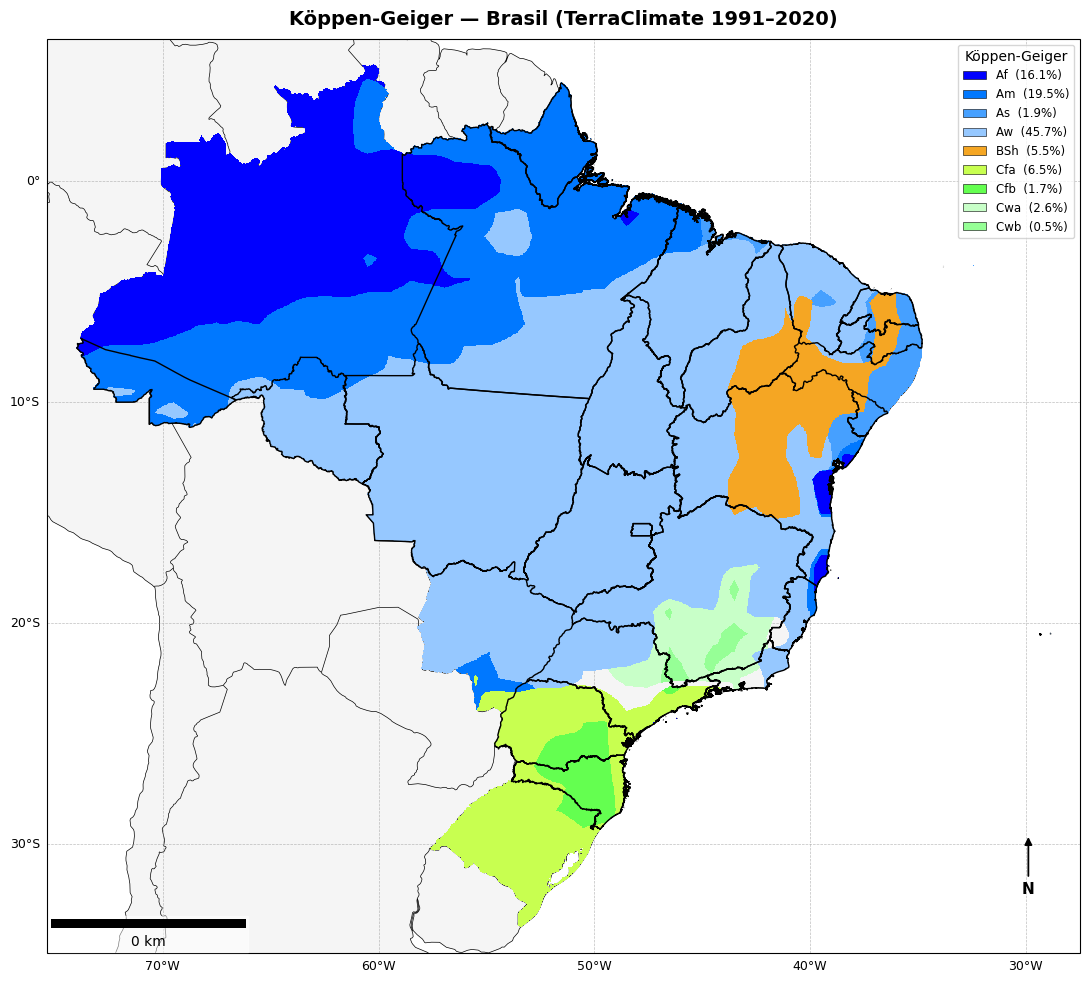

In [31]:
warnings.filterwarnings("ignore")
_ = plot_classification_cartopy(koppen_mosaic, koppen_transform, koppen_meta, KOPPEN_LABELS, KOPPEN_COLORS,
                                 'Köppen-Geiger — Brasil (TerraClimate 1991–2020)', is_named_palette=True,
                                 legend_title='Köppen-Geiger', savepath='koppen_brasil.png')

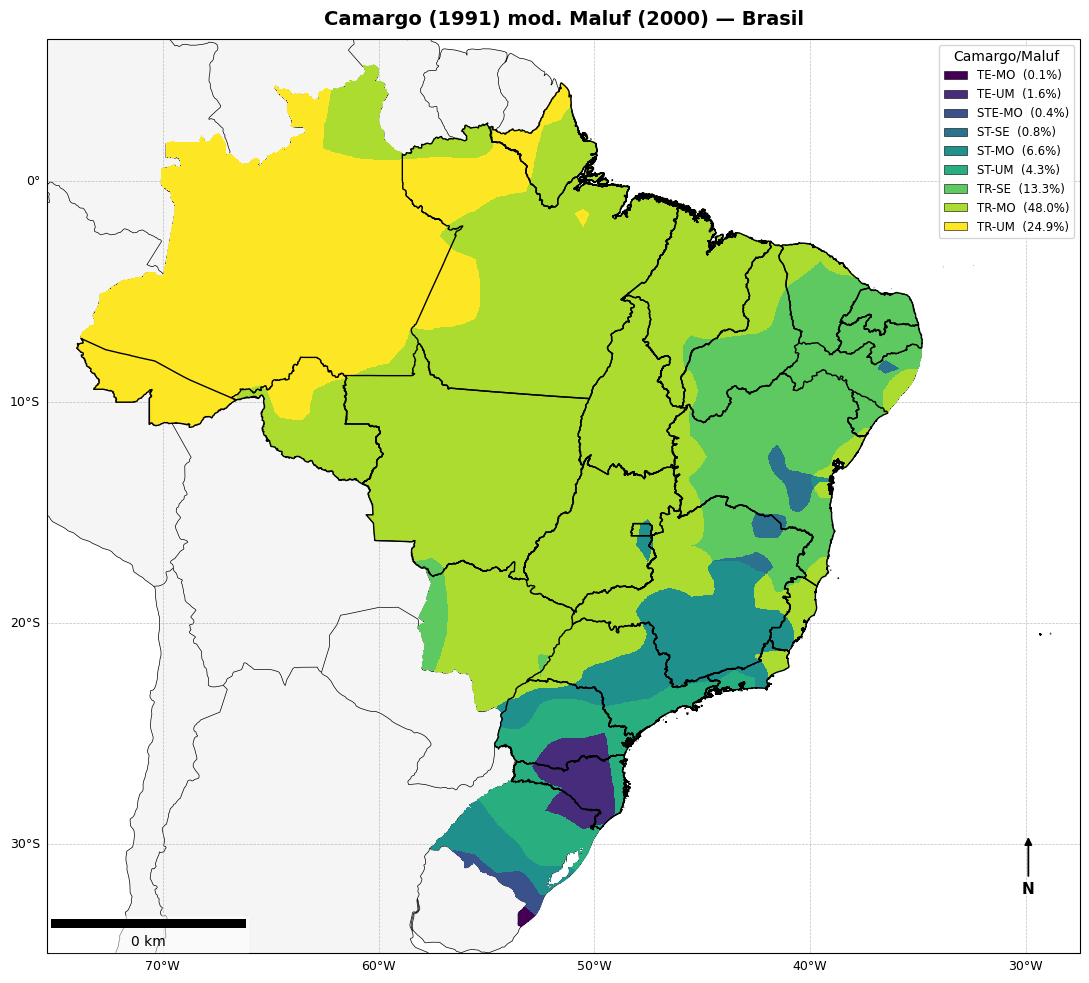

In [33]:
warnings.filterwarnings("ignore")
_ = plot_classification_cartopy(camargo_mosaic, camargo_transform, camargo_meta, CAMARGO_CODE_LABELS,
                                 plt.colormaps['viridis'], 'Camargo (1991) mod. Maluf (2000) — Brasil',
                                 legend_title='Camargo/Maluf', savepath='camargo_brasil.png')

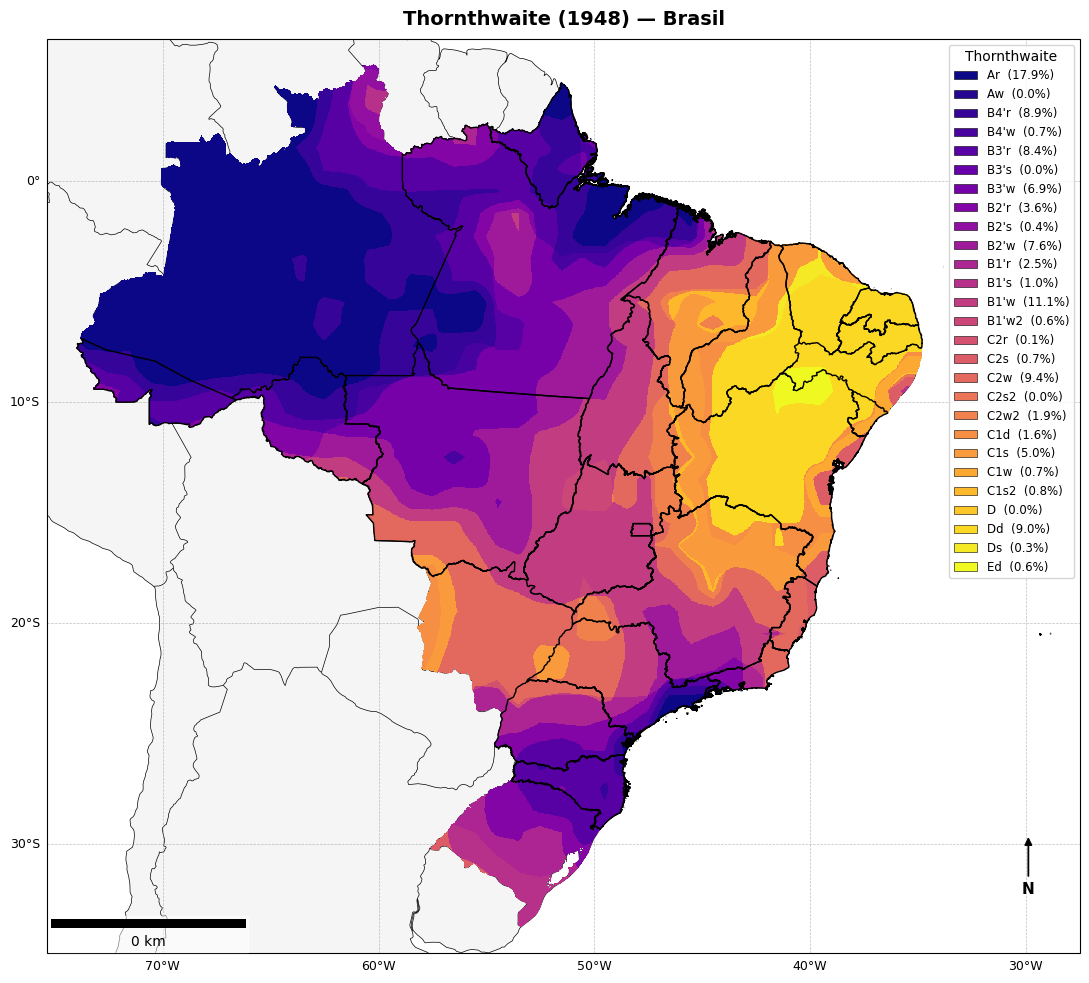

In [34]:
warnings.filterwarnings("ignore")
_ = plot_classification_cartopy(th_mosaic, th_transform, th_meta, TH_CODE_LABELS,
                                 plt.colormaps['plasma'], 'Thornthwaite (1948) — Brasil',
                                 legend_title='Thornthwaite', savepath='thornthwaite_brasil.png')

## 7. Estatísticas de área por classe — direto no servidor (sem baixar pixel a pixel)

`reduceRegion` com `Reducer.sum().group(...)` roda inteiramente no servidor do GEE e retorna só os
totais agregados — isso funciona para o Brasil inteiro sem o problema de memória do download bruto
(pode demorar alguns minutos pela quantidade de pixels processados, mas não estoura RAM local).

In [35]:
def area_stats(code_img, aoi_geom, scale, labels):
    pixel_area_ha = ee.Image.pixelArea().divide(10000).rename('area_ha')
    grouped = pixel_area_ha.addBands(code_img).reduceRegion(
        reducer=ee.Reducer.sum().group(groupField=1, groupName='cls'),
        geometry=aoi_geom, scale=scale, maxPixels=1e12, bestEffort=True, tileScale=4,
    )
    groups = grouped.getInfo().get('groups', [])
    total = sum(g['sum'] for g in groups)
    print(f"{'Classe':<10}{'Área (mil ha)':>16}{'% do Brasil':>13}")
    for g in sorted(groups, key=lambda x: -x['sum']):
        lbl = labels.get(int(g['cls']), '?')
        print(f"{lbl:<10}{g['sum']/1000:>16.1f}{100*g['sum']/total:>12.1f}%")

print('--- Köppen-Geiger ---'); area_stats(koppen_br, brazil_geom, NATIVE_SCALE, KOPPEN_LABELS)
print(); print('--- Camargo/Maluf ---'); area_stats(camargo_br, brazil_geom, NATIVE_SCALE, CAMARGO_CODE_LABELS)
print(); print('--- Thornthwaite ---'); area_stats(thornthwaite_br, brazil_geom, NATIVE_SCALE, TH_CODE_LABELS)

--- Köppen-Geiger ---
Classe       Área (mil ha)  % do Brasil
Aw                386097.4        45.8%
Am                166745.9        19.8%
Af                138810.4        16.5%
Cfa                49586.9         5.9%
BSh                47204.6         5.6%
Cwa                20786.9         2.5%
As                 15834.9         1.9%
Cfb                13316.9         1.6%
Cwb                 3737.3         0.4%

--- Camargo/Maluf ---
Classe       Área (mil ha)  % do Brasil
TR-MO             408922.9        48.2%
TR-UM             216689.8        25.5%
TR-SE             113591.1        13.4%
ST-MO              53260.8         6.3%
ST-UM              33301.5         3.9%
TE-UM              12700.4         1.5%
ST-SE               6792.2         0.8%
STE-MO              2906.5         0.3%
TE-MO                414.5         0.0%

--- Thornthwaite ---
Classe       Área (mil ha)  % do Brasil
Ar                154731.8        18.2%
B1'w               93575.1        11.0%
C2w          